**Justification:** Import required libraries for data handling, preprocessing, model building, ensemble learning, and evaluation metrics.

In [1]:
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline


from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from xgboost import XGBClassifier


from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

**Justification:** Load the sleep health dataset and preview the first rows to confirm that the file is read correctly.

In [2]:
df = pd.read_csv("Sleep_health_and_lifestyle_dataset (1).csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


**Justification:** Replace missing target values with `None` so all records have a valid class label for supervised classification.

In [3]:
df["Sleep Disorder"] = df["Sleep Disorder"].fillna("None")

**Justification:** Remove `Person ID` because it is only an identifier and should not influence model learning.

In [4]:
if "Person ID" in df.columns:
       df.drop(columns=["Person ID"], inplace=True)

**Justification:** Normalize BMI category labels and split blood pressure into numeric systolic and diastolic features for better model learning.

In [5]:
df["BMI Category"] = df["BMI Category"].replace({"Normal Weight": "Normal"})


# Split Blood Pressure
if "Blood Pressure" in df.columns:
       df[["Systolic_BP", "Diastolic_BP"]] = df["Blood Pressure"].str.split('/', expand=True).astype(int)
       df.drop(columns=["Blood Pressure"], inplace=True)

**Justification:** Separate input features from the target variable so the models learn to predict `Sleep Disorder` from the remaining columns.

In [6]:
X = df.drop(columns=["Sleep Disorder"])
y = df["Sleep Disorder"]

**Justification:** Encode text class labels into numeric labels because scikit-learn and XGBoost classifiers require numeric target values.

In [7]:
le = LabelEncoder()
y_encoded = le.fit_transform(y)


print("Classes:", le.classes_)

Classes: ['Insomnia' 'None' 'Sleep Apnea']


**Justification:** Define preprocessing for numeric and categorical columns so scaling and one-hot encoding are applied consistently inside each model pipeline.

In [8]:
categorical_cols = X.select_dtypes(include="object").columns
numerical_cols = X.select_dtypes(exclude="object").columns


preprocessor = ColumnTransformer(
transformers=[
("num", StandardScaler(), numerical_cols),
("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)]
)

**Justification:** Create the Random Forest pipeline as a strong tree-based baseline that can capture nonlinear feature interactions.

In [9]:
rf_model = Pipeline([
("preprocessor", preprocessor),
("classifier", RandomForestClassifier(
n_estimators=200,
random_state=42
))
])

**Justification:** Create the XGBoost pipeline as a boosted-tree model that often performs well on structured tabular classification tasks.

In [10]:
xgb_model = Pipeline([
("preprocessor", preprocessor),
("classifier", XGBClassifier(
n_estimators=200,
learning_rate=0.05,
max_depth=5,
eval_metric='mlogloss',
random_state=42
))
])

**Justification:** Create a soft-voting ensemble so Random Forest and XGBoost probabilities can be combined into one final prediction.

In [11]:
voting_clf = VotingClassifier(
estimators=[
('rf', rf_model),
('xgb', xgb_model)
],
voting='soft'
)

**Justification:** Split the dataset into stratified train and test sets so each sleep-disorder class keeps a similar proportion in both sets.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
X, y_encoded,
test_size=0.2,
stratify=y_encoded,
random_state=42
)

**Justification:** Train the soft-voting ensemble on the training data after all preprocessing is wrapped inside the model pipelines.

In [13]:
voting_clf.fit(X_train, y_train)

VotingClassifier(estimators=[('rf',
                              Pipeline(steps=[('preprocessor',
                                               ColumnTransformer(transformers=[('num',
                                                                                StandardScaler(),
                                                                                Index(['Age', 'Sleep Duration', 'Quality of Sleep', 'Physical Activity Level',
       'Stress Level', 'Heart Rate', 'Daily Steps', 'Systolic_BP',
       'Diastolic_BP'],
      dtype='object')),
                                                                               ('cat',
                                                                                OneHotEncoder(handle_unknown='ignore'),
                                                                                Index(['Gender', 'Occupati...
                                                             grow_policy=None,
                                                             importance_type=None,
                                                             interaction_constraints=None,
                                                             learning_rate=0.05,
                                                             max_bin=None,
                                                             max_cat_threshold=None,
                                                             max_cat_to_onehot=None,
                                                             max_delta_step=None,
                                                             max_depth=5,
                                                             max_leaves=None,
                                                             min_child_weight=None,
                                                             missing=nan,
                                                             monotone_constraints=None,
                                                             multi_strategy=None,
                                                             n_estimators=200,
                                                             n_jobs=None,
                                                             num_parallel_tree=None,
                                                             random_state=42, ...))]))],
                 voting='soft')

**Justification:** Evaluate the ensemble with accuracy, class-wise precision, recall, F1-score, and the confusion matrix.

In [14]:
y_pred = voting_clf.predict(X_test)


acc = accuracy_score(y_test, y_pred)
print(f"Final Accuracy: {acc*100:.2f}%")


print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=le.classes_))


print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Final Accuracy: 93.33%

Classification Report:

              precision    recall  f1-score   support

    Insomnia       0.78      0.93      0.85        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.93      0.81      0.87        16

    accuracy                           0.93        75
   macro avg       0.90      0.91      0.90        75
weighted avg       0.94      0.93      0.93        75

Confusion Matrix:

[[14  0  1]
 [ 1 43  0]
 [ 3  0 13]]


**Justification:** Visualize the confusion matrix as a heatmap so correct and incorrect predictions are easier to inspect.

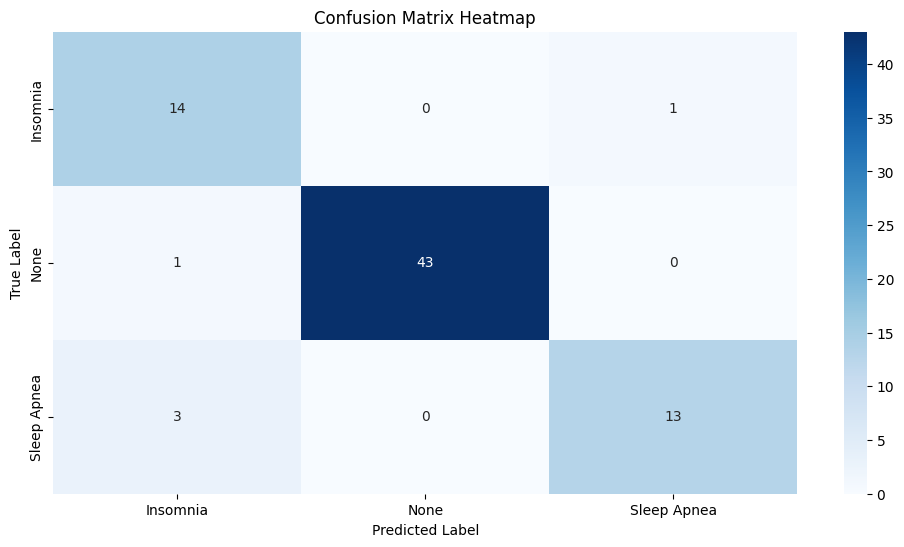

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns


cm = confusion_matrix(y_test, y_pred)


plt.figure(figsize=(12,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
xticklabels=le.classes_,
yticklabels=le.classes_)


plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix Heatmap')
plt.show()

## Model Comparison

This section is justified because it compares all candidate models under the same data split and metrics, making model selection easier and more transparent.

**Justification:** Compare multiple algorithms on the same train/test split to identify which model performs best for this dataset.

Training extra baseline models...
Logistic Regression trained in 0.030 sec
Decision Tree trained in 0.007 sec
KNN trained in 0.006 sec
SVM trained in 0.019 sec


Gradient Boosting trained in 0.307 sec

Model Comparison Table


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,prediction_time_sec
0,SVM,0.9733,0.9630,0.9556,0.9566,0.9763,0.9733,0.9732,0.005047
1,Decision Tree,0.9467,0.9191,0.9418,0.9297,0.9499,0.9467,0.9476,0.002788
2,KNN,0.9467,0.9285,0.9285,0.9279,0.9474,0.9467,0.9467,0.053936
3,Random Forest,0.9467,0.9163,0.9271,0.9214,0.9482,0.9467,0.9472,0.012599
4,Gradient Boosting,0.9467,0.9163,0.9271,0.9214,0.9482,0.9467,0.9472,0.004256
5,Logistic Regression,0.9467,0.9217,0.9258,0.9200,0.9509,0.9467,0.9464,0.003079
6,XGBoost,0.9467,0.9174,0.9153,0.9139,0.9495,0.9467,0.9466,0.003863
7,Soft Voting Ensemble,0.9333,0.9021,0.9077,0.9012,0.9403,0.9333,0.9345,0.016118


Best model by accuracy + F1: SVM


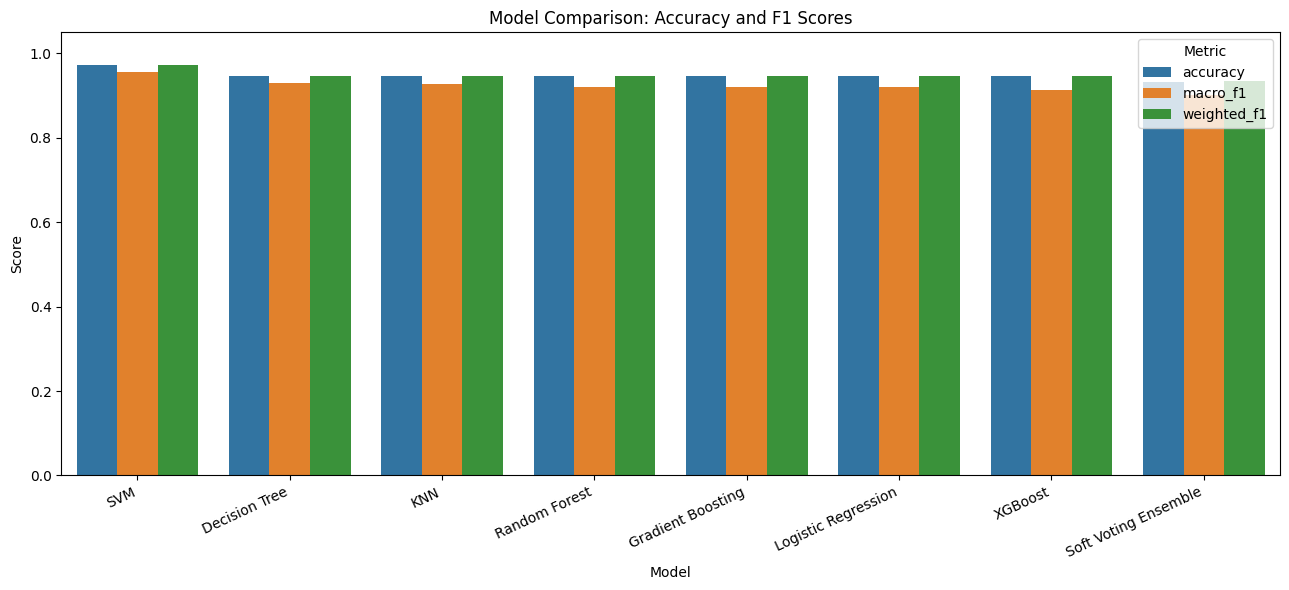

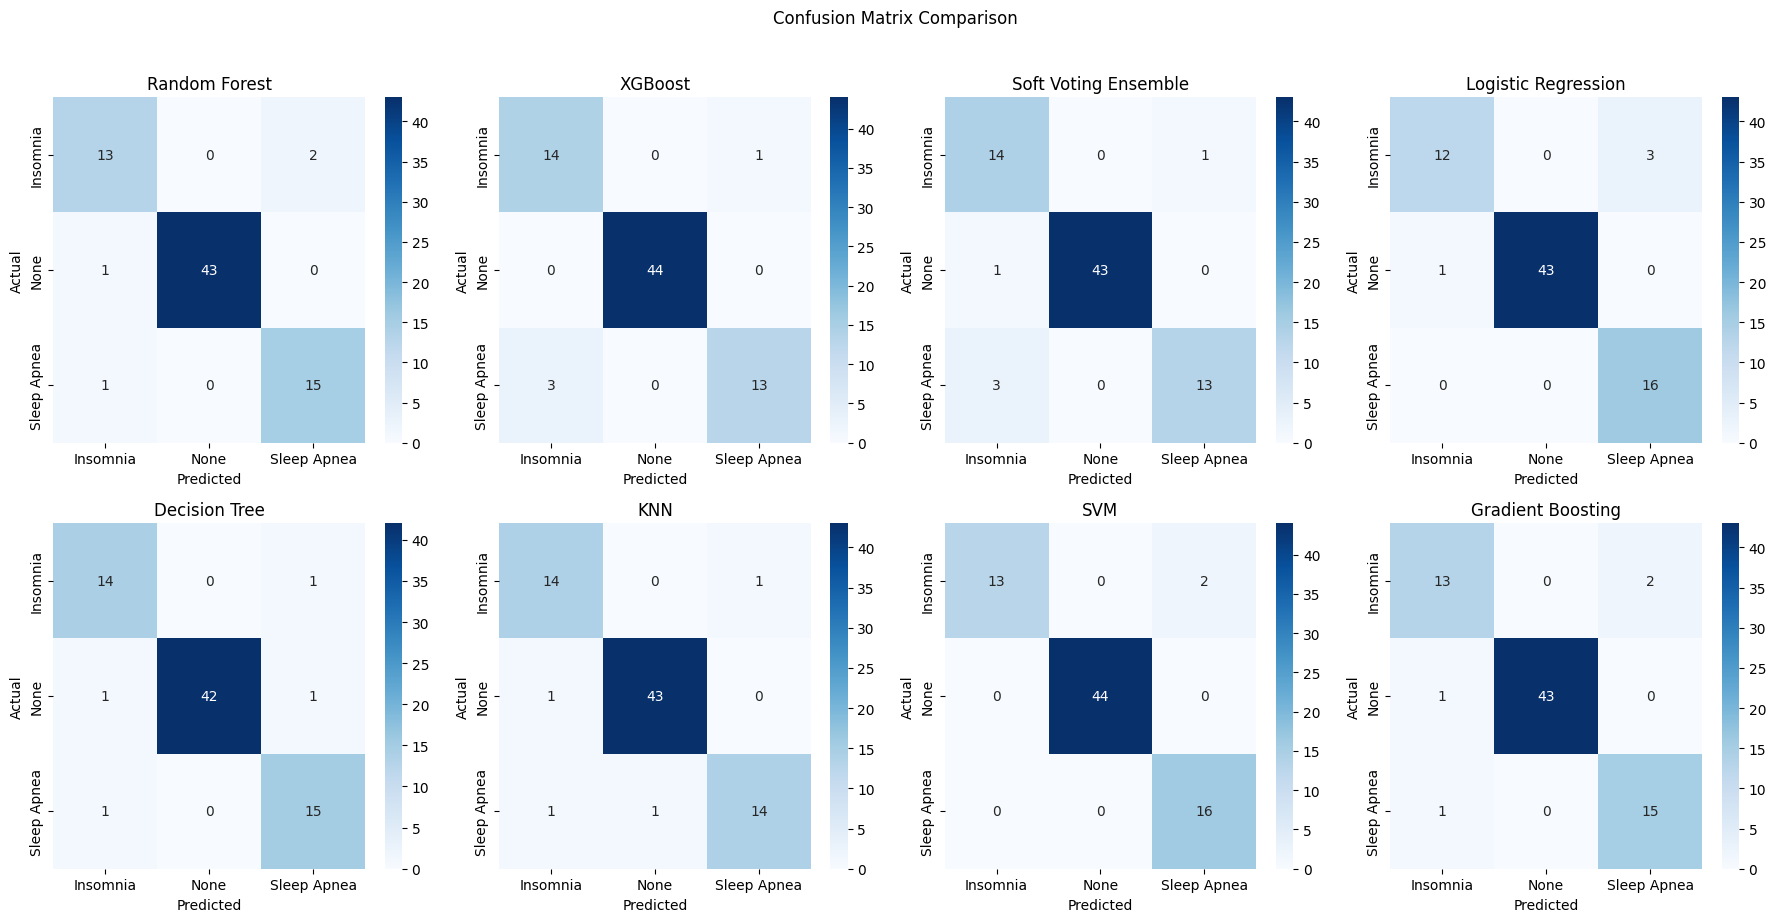

Detailed Classification Reports

Random Forest
              precision    recall  f1-score   support

    Insomnia       0.87      0.87      0.87        15
        None       1.00      0.98      0.99        44
 Sleep Apnea       0.88      0.94      0.91        16

    accuracy                           0.95        75
   macro avg       0.92      0.93      0.92        75
weighted avg       0.95      0.95      0.95        75


XGBoost
              precision    recall  f1-score   support

    Insomnia       0.82      0.93      0.88        15
        None       1.00      1.00      1.00        44
 Sleep Apnea       0.93      0.81      0.87        16

    accuracy                           0.95        75
   macro avg       0.92      0.92      0.91        75
weighted avg       0.95      0.95      0.95        75


Soft Voting Ensemble
              precision    recall  f1-score   support

    Insomnia       0.78      0.93      0.85        15
        None       1.00      0.98      0.99        

In [16]:
# Compare all models side by side on the same train/test split.
from sklearn.metrics import precision_recall_fscore_support
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
import time

baseline_models = {
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=3000, random_state=42))
    ]),
    "Decision Tree": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(random_state=42))
    ]),
    "KNN": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(n_neighbors=5))
    ]),
    "SVM": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", SVC(kernel="rbf", probability=True, random_state=42))
    ]),
    "Gradient Boosting": Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", GradientBoostingClassifier(random_state=42))
    ]),
}

fitted_models_to_compare = {
    "Random Forest": voting_clf.named_estimators_["rf"],
    "XGBoost": voting_clf.named_estimators_["xgb"],
    "Soft Voting Ensemble": voting_clf,
}

print("Training extra baseline models...")
for model_name, model_obj in baseline_models.items():
    fit_start = time.perf_counter()
    model_obj.fit(X_train, y_train)
    fit_time = time.perf_counter() - fit_start
    fitted_models_to_compare[model_name] = model_obj
    print(f"{model_name} trained in {fit_time:.3f} sec")

comparison_rows = []
predictions_by_model = {}

for model_name, model_obj in fitted_models_to_compare.items():
    start_time = time.perf_counter()
    model_pred = model_obj.predict(X_test)
    prediction_time = time.perf_counter() - start_time
    predictions_by_model[model_name] = model_pred

    macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
        y_test, model_pred, average="macro", zero_division=0
    )
    weighted_precision, weighted_recall, weighted_f1, _ = precision_recall_fscore_support(
        y_test, model_pred, average="weighted", zero_division=0
    )

    comparison_rows.append({
        "model": model_name,
        "accuracy": accuracy_score(y_test, model_pred),
        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,
        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,
        "prediction_time_sec": prediction_time,
    })

model_comparison_df = pd.DataFrame(comparison_rows).sort_values(
    ["accuracy", "macro_f1", "weighted_f1"], ascending=False
).reset_index(drop=True)

print("\nModel Comparison Table")
model_comparison_display = model_comparison_df.copy()
for metric_col in [
    "accuracy", "macro_precision", "macro_recall", "macro_f1",
    "weighted_precision", "weighted_recall", "weighted_f1"
]:
    model_comparison_display[metric_col] = model_comparison_display[metric_col].round(4)
model_comparison_display["prediction_time_sec"] = model_comparison_display["prediction_time_sec"].round(6)
display(model_comparison_display)

best_model_name = model_comparison_df.loc[0, "model"]
print(f"Best model by accuracy + F1: {best_model_name}")

plt.figure(figsize=(13, 6))
metric_plot_df = model_comparison_df.melt(
    id_vars="model",
    value_vars=["accuracy", "macro_f1", "weighted_f1"],
    var_name="metric",
    value_name="score",
)
sns.barplot(data=metric_plot_df, x="model", y="score", hue="metric")
plt.ylim(0, 1.05)
plt.title("Model Comparison: Accuracy and F1 Scores")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=25, ha="right")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

n_models = len(fitted_models_to_compare)
n_cols = 4
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4.5 * n_rows))
axes = np.asarray(axes).reshape(-1)

for ax, (model_name, model_pred) in zip(axes, predictions_by_model.items()):
    cm_model = confusion_matrix(y_test, model_pred)
    sns.heatmap(
        cm_model,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_,
        ax=ax,
    )
    ax.set_title(model_name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

for ax in axes[len(fitted_models_to_compare):]:
    ax.axis("off")

plt.suptitle("Confusion Matrix Comparison", y=1.02)
plt.tight_layout()
plt.show()

print("Detailed Classification Reports")
for model_name, model_pred in predictions_by_model.items():
    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print(classification_report(y_test, model_pred, target_names=le.classes_, zero_division=0))

## XAI: Feature Importance, SHAP, and LIME

This section is justified because explainable AI helps interpret which features influence both global model behavior and individual predictions.

**Justification:** Verify and import SHAP and LIME dependencies because these packages are required for explainable AI analysis.

In [17]:
# Install/verify XAI dependencies used below.
import importlib.util
import subprocess
import sys

required_packages = {
    "shap": "shap==0.46.0",
    "lime": "lime",
}

for import_name, package_name in required_packages.items():
    if importlib.util.find_spec(import_name) is None:
        print(f"Installing {package_name}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", package_name])

import shap
from lime.lime_tabular import LimeTabularExplainer

print("XAI packages ready")
print("SHAP version:", shap.__version__)

XAI packages ready
SHAP version: 0.46.0


**Justification:** Extract fitted preprocessors, transformed matrices, feature names, and trained estimators needed for feature importance, SHAP, and LIME.

In [18]:
# Prepare transformed feature matrix and fitted estimators for XAI.
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

rf_pipeline = voting_clf.named_estimators_["rf"]
xgb_pipeline = voting_clf.named_estimators_["xgb"]

fitted_preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_classifier = rf_pipeline.named_steps["classifier"]
xgb_classifier = xgb_pipeline.named_steps["classifier"]

feature_names = fitted_preprocessor.get_feature_names_out()

X_train_processed = fitted_preprocessor.transform(X_train)
X_test_processed = fitted_preprocessor.transform(X_test)

def to_dense(matrix):
    return matrix.toarray() if hasattr(matrix, "toarray") else np.asarray(matrix)

X_train_xai = to_dense(X_train_processed)
X_test_xai = to_dense(X_test_processed)

sample_size = min(50, X_test_xai.shape[0])
X_shap_sample = X_test_xai[:sample_size]

print("Transformed train shape:", X_train_xai.shape)
print("Transformed test shape:", X_test_xai.shape)
print("Number of XAI features:", len(feature_names))
print("Class labels:", list(le.classes_))

Transformed train shape: (299, 25)
Transformed test shape: (75, 25)
Number of XAI features: 25
Class labels: ['Insomnia', 'None', 'Sleep Apnea']


**Justification:** Calculate global feature importance from Random Forest and XGBoost to identify which variables contribute most overall.

Top 15 global feature importances:


,feature,random_forest_importance,xgboost_importance,mean_importance
0,cat__BMI Category_Normal,0.115746,0.700890,0.408318
1,num__Systolic_BP,0.138850,0.123480,0.131165
2,cat__BMI Category_Overweight,0.128236,0.002020,0.065128
3,num__Diastolic_BP,0.104175,0.013382,0.058778
4,num__Physical Activity Level,0.049754,0.064994,0.057374
5,num__Sleep Duration,0.097824,0.003704,0.050764
6,num__Age,0.095972,0.004352,0.050162
7,cat__Occupation_Nurse,0.055603,0.021705,0.038654
8,num__Heart Rate,0.048030,0.022204,0.035117
9,num__Daily Steps,0.044386,0.006225,0.025305


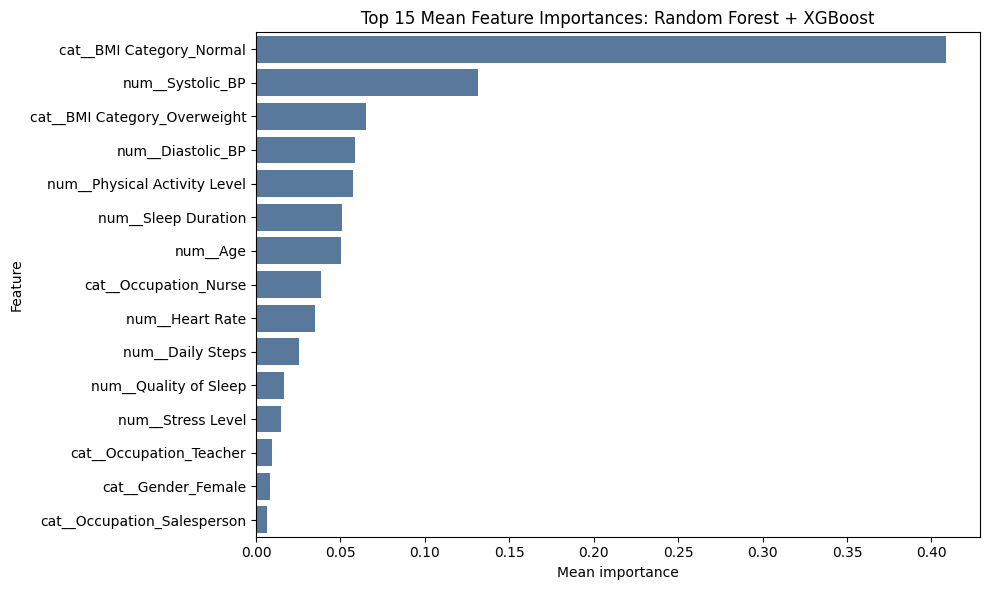

In [19]:
# Global feature importance from Random Forest and XGBoost inside the voting ensemble.
rf_importance = rf_classifier.feature_importances_
xgb_importance = xgb_classifier.feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "random_forest_importance": rf_importance,
    "xgboost_importance": xgb_importance,
})
importance_df["mean_importance"] = importance_df[[
    "random_forest_importance",
    "xgboost_importance"
]].mean(axis=1)
importance_df = importance_df.sort_values("mean_importance", ascending=False).reset_index(drop=True)

print("Top 15 global feature importances:")
display(importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=importance_df.head(15),
    x="mean_importance",
    y="feature",
    color="#4C78A8",
)
plt.title("Top 15 Mean Feature Importances: Random Forest + XGBoost")
plt.xlabel("Mean importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

**Justification:** Use SHAP to estimate feature effects for the fitted XGBoost model and show both global and class-specific explanations.

SHAP calculated on 50 test rows using the fitted XGBoost model.
Top 15 SHAP features:


,feature,mean_abs_shap,shap_Insomnia,shap_None,shap_Sleep Apnea
0,num__Systolic_BP,0.808354,0.606275,0.936423,0.882365
1,num__Age,0.399244,0.466025,0.349255,0.382452
2,num__Physical Activity Level,0.341988,0.873797,0.010259,0.141909
3,num__Sleep Duration,0.251761,0.304112,0.275568,0.175601
4,cat__BMI Category_Normal,0.233941,0.000000,0.689871,0.011952
5,num__Daily Steps,0.166188,0.227561,0.142654,0.128350
6,num__Heart Rate,0.156977,0.062499,0.075523,0.332910
7,num__Diastolic_BP,0.076348,0.048672,0.001735,0.178635
8,num__Quality of Sleep,0.076017,0.105417,0.068414,0.054220
9,cat__Occupation_Accountant,0.075276,0.216052,0.009776,0.000000


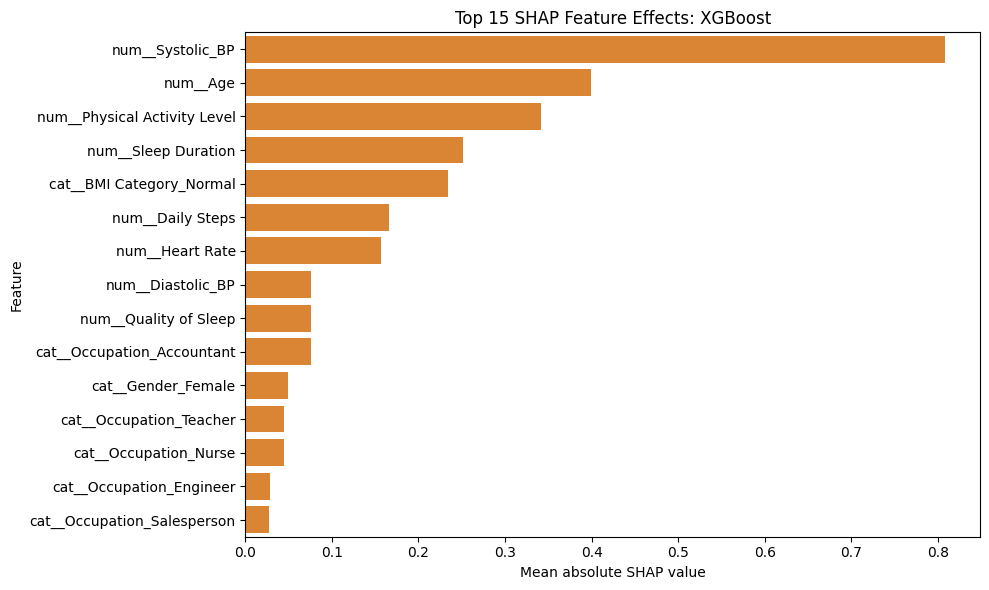

SHAP summary plot for class: Insomnia


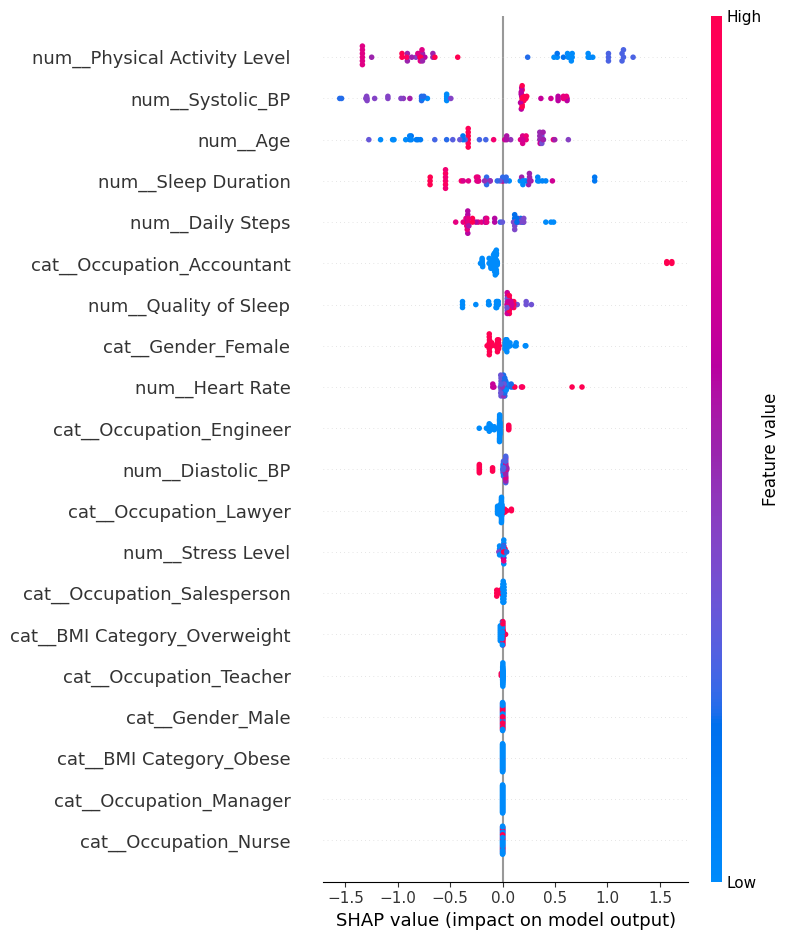

In [20]:
# SHAP global explanation for the fitted XGBoost model.
shap_explainer = shap.TreeExplainer(xgb_classifier)
shap_values = shap_explainer.shap_values(X_shap_sample)

if isinstance(shap_values, list):
    shap_array = np.stack(shap_values, axis=-1)
else:
    shap_array = np.asarray(shap_values)

if shap_array.ndim == 3:
    mean_abs_shap = np.abs(shap_array).mean(axis=(0, 2))
    shap_class_details = {
        f"shap_{class_name}": np.abs(shap_array[:, :, class_idx]).mean(axis=0)
        for class_idx, class_name in enumerate(le.classes_)
    }
else:
    mean_abs_shap = np.abs(shap_array).mean(axis=0)
    shap_class_details = {}

shap_importance_df = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap,
    **shap_class_details,
}).sort_values("mean_abs_shap", ascending=False).reset_index(drop=True)

print(f"SHAP calculated on {sample_size} test rows using the fitted XGBoost model.")
print("Top 15 SHAP features:")
display(shap_importance_df.head(15))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=shap_importance_df.head(15),
    x="mean_abs_shap",
    y="feature",
    color="#F58518",
)
plt.title("Top 15 SHAP Feature Effects: XGBoost")
plt.xlabel("Mean absolute SHAP value")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# Beeswarm-style summary for the predicted class of the first explained row.
if shap_array.ndim == 3:
    explained_class_idx = int(xgb_classifier.predict(X_shap_sample[:1])[0])
    print("SHAP summary plot for class:", le.classes_[explained_class_idx])
    shap.summary_plot(
        shap_array[:, :, explained_class_idx],
        X_shap_sample,
        feature_names=feature_names,
        show=False,
    )
else:
    shap.summary_plot(shap_array, X_shap_sample, feature_names=feature_names, show=False)
plt.tight_layout()
plt.show()

**Justification:** Use LIME to explain one individual prediction for all sleep-disorder classes using the same soft-voting probability logic.

LIME explanation for test instance: 0
Actual class: Insomnia
Predicted class: Insomnia
Prediction probabilities:


,Insomnia,None,Sleep Apnea
0,0.986588,0.012022,0.00139


Top 10 LIME rules for predicted class:


,feature_rule,lime_weight
0,num__Physical Activity Level <= -0.70,0.144209
1,0.19 < num__Systolic_BP <= 0.84,0.106712
2,cat__Occupation_Sales Representative <= 0.00,0.064088
3,cat__BMI Category_Normal <= 0.00,0.057554
4,cat__Occupation_Accountant <= 0.00,-0.056332
5,num__Daily Steps <= -0.54,0.046049
6,0.06 < num__Diastolic_BP <= 0.86,0.037816
7,cat__Occupation_Manager <= 0.00,0.036932
8,0.00 < cat__BMI Category_Overweight <= 1.00,0.030232
9,0.09 < num__Age <= 0.90,0.029313


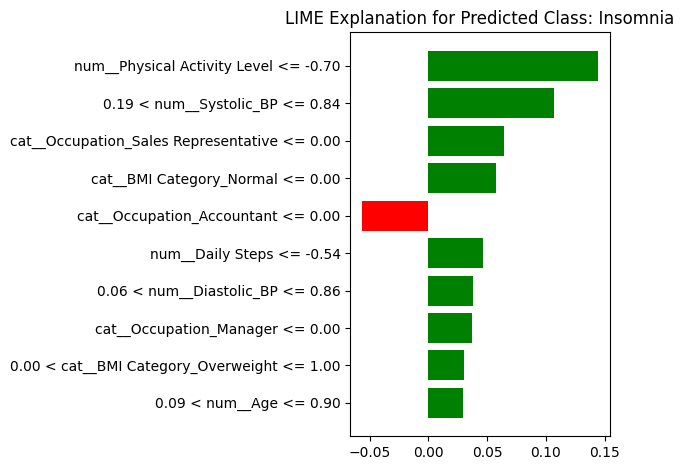

In [21]:
# LIME local explanation for one test instance using the soft-voting ensemble probabilities.
def ensemble_predict_proba_processed(data):
    data = np.asarray(data)
    return (
        rf_classifier.predict_proba(data) +
        xgb_classifier.predict_proba(data)
    ) / 2

lime_explainer = LimeTabularExplainer(
    training_data=X_train_xai,
    feature_names=list(feature_names),
    class_names=list(le.classes_),
    mode="classification",
    discretize_continuous=True,
    random_state=42,
)

instance_idx = 0
instance = X_test_xai[instance_idx]
predicted_class_idx = int(voting_clf.predict(X_test.iloc[[instance_idx]])[0])
predicted_label = le.classes_[predicted_class_idx]
actual_label = le.classes_[y_test[instance_idx]]

lime_exp = lime_explainer.explain_instance(
    data_row=instance,
    predict_fn=ensemble_predict_proba_processed,
    num_features=10,
    top_labels=len(le.classes_),
)

lime_table = pd.DataFrame(
    lime_exp.as_list(label=predicted_class_idx),
    columns=["feature_rule", "lime_weight"],
)

print("LIME explanation for test instance:", instance_idx)
print("Actual class:", actual_label)
print("Predicted class:", predicted_label)
print("Prediction probabilities:")
display(pd.DataFrame(
    [ensemble_predict_proba_processed(instance.reshape(1, -1))[0]],
    columns=le.classes_,
))

print("Top 10 LIME rules for predicted class:")
display(lime_table)

lime_exp.as_pyplot_figure(label=predicted_class_idx)
plt.title(f"LIME Explanation for Predicted Class: {predicted_label}")
plt.tight_layout()
plt.show()

**Justification:** Generate a paper-style LIME figure with predicted probability, positive/negative feature contributions, and feature values.

Paper-style LIME figure
Test instance: 0
Actual class: Insomnia
Explained/predicted class: Insomnia
Predicted probability: 0.9866


,rank,feature,feature_rule,feature_value,lime_weight,direction
0,1,num__Physical Activity Level,num__Physical Activity Level <= -0.70,-0.704188,0.144149,positive
1,2,num__Systolic_BP,0.19 < num__Systolic_BP <= 0.84,0.836185,0.130209,positive
2,3,cat__Occupation_Accountant,cat__Occupation_Accountant <= 0.00,0.000000,-0.073178,negative
3,4,cat__BMI Category_Normal,cat__BMI Category_Normal <= 0.00,0.000000,0.071470,positive
4,5,num__Diastolic_BP,0.06 < num__Diastolic_BP <= 0.86,0.864956,0.048934,positive
5,6,num__Daily Steps,num__Daily Steps <= -0.54,-0.540934,0.043109,positive
6,7,cat__BMI Category_Obese,cat__BMI Category_Obese <= 0.00,0.000000,-0.041137,negative
7,8,cat__Occupation_Manager,cat__Occupation_Manager <= 0.00,0.000000,0.032060,positive


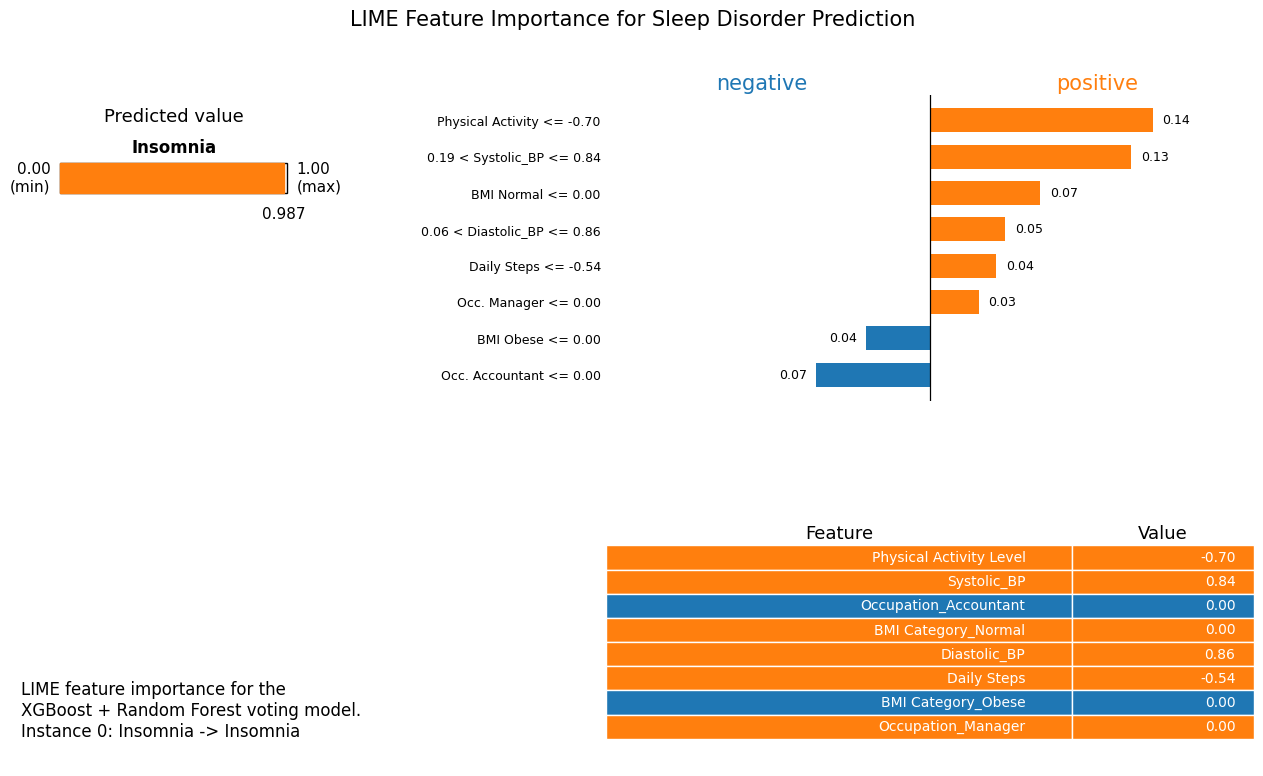

Saved figure: lime_sleep_disorder_paper_style.png


In [22]:
# Paper-style LIME visualization matching the requested format.
# This uses the selected test instance and the predicted Sleep Disorder class.
from matplotlib.patches import Rectangle

paper_instance_idx = 0
paper_instance = X_test_xai[paper_instance_idx]
paper_probs = ensemble_predict_proba_processed(paper_instance.reshape(1, -1))[0]
paper_predicted_class_idx = int(np.argmax(paper_probs))
paper_predicted_label = le.classes_[paper_predicted_class_idx]
paper_actual_label = le.classes_[y_test[paper_instance_idx]]

paper_lime_exp = lime_explainer.explain_instance(
    data_row=paper_instance,
    predict_fn=ensemble_predict_proba_processed,
    num_features=8,
    labels=[paper_predicted_class_idx],
)

lime_rules = paper_lime_exp.as_list(label=paper_predicted_class_idx)
lime_feature_map = paper_lime_exp.as_map()[paper_predicted_class_idx]

paper_rows = []
for rank, ((feature_rule, lime_weight), (feature_idx, _)) in enumerate(
    zip(lime_rules, lime_feature_map), start=1
):
    paper_rows.append({
        "rank": rank,
        "feature": str(feature_names[feature_idx]),
        "feature_rule": feature_rule,
        "feature_value": float(paper_instance[feature_idx]),
        "lime_weight": float(lime_weight),
        "direction": "positive" if lime_weight > 0 else "negative",
    })

paper_lime_df = pd.DataFrame(paper_rows)
print("Paper-style LIME figure")
print("Test instance:", paper_instance_idx)
print("Actual class:", paper_actual_label)
print("Explained/predicted class:", paper_predicted_label)
print("Predicted probability:", round(float(paper_probs[paper_predicted_class_idx]), 4))
display(paper_lime_df)

fig = plt.figure(figsize=(13.5, 8.5))

# Left predicted-probability gauge.
ax_gauge = fig.add_axes([0.04, 0.57, 0.24, 0.30])
ax_gauge.axis("off")
prob = float(paper_probs[paper_predicted_class_idx])
gauge_x, gauge_y, gauge_w, gauge_h = 0.15, 0.58, 0.70, 0.12
ax_gauge.text(0.5, 0.88, "Predicted value", ha="center", va="center", fontsize=13)
ax_gauge.text(0.5, 0.76, paper_predicted_label, ha="center", va="center", fontsize=12, fontweight="bold")
ax_gauge.add_patch(Rectangle((gauge_x, gauge_y), gauge_w, gauge_h, fill=False, edgecolor="black", linewidth=1.0))
ax_gauge.add_patch(Rectangle((gauge_x, gauge_y), gauge_w * prob, gauge_h, color="#ff7f0e"))
ax_gauge.text(gauge_x - 0.03, gauge_y + gauge_h / 2, "0.00\n(min)", ha="right", va="center", fontsize=11)
ax_gauge.text(gauge_x + gauge_w + 0.03, gauge_y + gauge_h / 2, "1.00\n(max)", ha="left", va="center", fontsize=11)
ax_gauge.text(gauge_x + gauge_w * prob, gauge_y - 0.08, f"{prob:.3f}", ha="center", va="center", fontsize=11)
ax_gauge.set_xlim(0, 1)
ax_gauge.set_ylim(0, 1)

# Right negative/positive contribution bars.
ax_bar = fig.add_axes([0.48, 0.50, 0.48, 0.36])
plot_df = paper_lime_df.copy().sort_values("lime_weight", ascending=True)
plot_df["rule_short"] = (
    plot_df["feature_rule"]
    .str.replace("num__", "", regex=False)
    .str.replace("cat__", "", regex=False)
    .str.replace("Physical Activity Level", "Physical Activity", regex=False)
    .str.replace("BMI Category_", "BMI ", regex=False)
    .str.replace("Occupation_", "Occ. ", regex=False)
    .str.slice(0, 34)
)
y_positions = np.arange(len(plot_df))
colors = plot_df["lime_weight"].apply(lambda value: "#ff7f0e" if value > 0 else "#1f77b4")
ax_bar.barh(y_positions, plot_df["lime_weight"], color=colors, height=0.66)
ax_bar.axvline(0, color="black", linewidth=0.9)
ax_bar.set_yticks(y_positions)
ax_bar.set_yticklabels(plot_df["rule_short"], fontsize=9)
ax_bar.tick_params(axis="x", bottom=False, labelbottom=False)
ax_bar.tick_params(axis="y", length=0)
for spine in ax_bar.spines.values():
    spine.set_visible(False)
max_abs_weight = max(abs(plot_df["lime_weight"]).max(), 0.01)
ax_bar.set_xlim(-max_abs_weight * 1.45, max_abs_weight * 1.45)
ax_bar.text(-max_abs_weight * 0.75, len(plot_df) - 0.15, "negative", color="#1f77b4", fontsize=15, ha="center")
ax_bar.text(max_abs_weight * 0.75, len(plot_df) - 0.15, "positive", color="#ff7f0e", fontsize=15, ha="center")
for y, value in zip(y_positions, plot_df["lime_weight"]):
    label_x = value + (0.006 if value >= 0 else -0.006)
    ax_bar.text(label_x, y, f"{abs(value):.2f}", va="center", ha="left" if value >= 0 else "right", fontsize=9)

# Feature value table.
ax_table = fig.add_axes([0.48, 0.08, 0.48, 0.30])
ax_table.axis("off")
table_df = paper_lime_df[["feature", "feature_value", "direction"]].copy()
table_df["feature"] = table_df["feature"].str.replace("num__", "", regex=False).str.replace("cat__", "", regex=False)
table_df["feature"] = table_df["feature"].str.slice(0, 36)
table_df["feature_value"] = table_df["feature_value"].map(lambda value: f"{value:.2f}")
cell_text = table_df[["feature", "feature_value"]].values.tolist()
row_colors = table_df["direction"].map({"positive": "#ff7f0e", "negative": "#1f77b4"}).tolist()
table = ax_table.table(
    cellText=cell_text,
    colLabels=["Feature", "Value"],
    cellLoc="right",
    colLoc="center",
    colWidths=[0.72, 0.28],
    loc="center",
)
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.0, 1.45)
for (row, col), cell in table.get_celld().items():
    cell.set_edgecolor("white")
    if row == 0:
        cell.set_facecolor("white")
        cell.set_text_props(color="black", fontsize=13)
    else:
        cell.set_facecolor(row_colors[row - 1])
        cell.set_text_props(color="white")

ax_caption = fig.add_axes([0.04, 0.07, 0.34, 0.20])
ax_caption.axis("off")
ax_caption.text(
    0.02,
    0.15,
    f"LIME feature importance for the\nXGBoost + Random Forest voting model.\nInstance {paper_instance_idx}: {paper_actual_label} -> {paper_predicted_label}",
    ha="left",
    va="bottom",
    fontsize=12,
)

fig.suptitle("LIME Feature Importance for Sleep Disorder Prediction", y=0.96, fontsize=15)
plt.savefig("lime_sleep_disorder_paper_style.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved figure: lime_sleep_disorder_paper_style.png")

## Random Forest + XGBoost stacking confusion matrix

This section trains a stacking ensemble using Random Forest and XGBoost as base learners, then visualizes its held-out test predictions.

In [1]:
from sklearn.base import clone
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

# A separate stacking pipeline; the existing soft-voting model remains unchanged.
stacking_cm_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", StackingClassifier(
        estimators=[
            ("rf", RandomForestClassifier(n_estimators=200, random_state=42)),
            ("xgb", XGBClassifier(
                n_estimators=200, learning_rate=0.05, max_depth=5,
                eval_metric="mlogloss", random_state=42,
            )),
        ],
        final_estimator=LogisticRegression(max_iter=4000),
        stack_method="predict_proba",
        n_jobs=-1,
    )),
])

stacking_cm_model.fit(X_train, y_train)
stacking_cm_predictions = stacking_cm_model.predict(X_test)
stacking_cm = confusion_matrix(y_test, stacking_cm_predictions)
stacking_cm_percent = stacking_cm / stacking_cm.sum(axis=1, keepdims=True) * 100

stacking_annotations = np.array([
    [f"{count}\n({percentage:.1f}%)" for count, percentage in zip(count_row, percent_row)]
    for count_row, percent_row in zip(stacking_cm, stacking_cm_percent)
])

fig, ax = plt.subplots(figsize=(8.2, 6.8), facecolor="white")
sns.heatmap(
    stacking_cm, annot=stacking_annotations, fmt="", cmap="Blues", square=True,
    xticklabels=le.classes_, yticklabels=le.classes_, linewidths=1.2,
    linecolor="white", cbar_kws={"label": "Number of samples"}, ax=ax,
)
ax.set_title("Stacking Classifier (RF + XGBoost) — Confusion Matrix", fontsize=14, fontweight="bold", pad=13)
ax.set_xlabel("Predicted label", fontweight="bold")
ax.set_ylabel("True label", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"STACKING ACCURACY: {accuracy_score(y_test, stacking_cm_predictions) * 100:.2f}%")
print(classification_report(y_test, stacking_cm_predictions, target_names=le.classes_))


NameError: name 'Pipeline' is not defined